<a href="https://colab.research.google.com/github/Thriveni2026/Google-page-rank/blob/main/Maths_abhyan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

   import numpy as np
import matplotlib.pyplot as plt

In [ ]:
pages = ["A", "B", "C", "D"]

links = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A"],
    "D": ["C"]
}

print("Pages:", pages)
print("Links:")
for page in pages:
    print(page, "→", links[page])

Pages: ['A', 'B', 'C', 'D']
Links:
A → ['B', 'C']
B → ['C']
C → ['A']
D → ['C']


In [ ]:
n = len(pages)

M = np.zeros((n, n))

for j, page in enumerate(pages):
    outgoing = links[page]

    if len(outgoing) == 0:
        M[:, j] = 1 / n
    else:
        for destination in outgoing:
            i = pages.index(destination)
            M[i, j] = 1 / len(outgoing)

print("Transition Matrix M:")
print(M)

Transition Matrix M:
[[0.  0.  1.  0. ]
 [0.5 0.  0.  0. ]
 [0.5 1.  0.  1. ]
 [0.  0.  0.  0. ]]


In [ ]:
rank = np.ones(n) / n

print("Initial PageRank:")
print(rank)

for iteration in range(100):
    new_rank = M @ rank

    if np.allclose(rank, new_rank):
        break

    rank = new_rank

print("\nFinal PageRank:")
for page, value in zip(pages, rank):
    print(page, "=", round(value, 4))

print("\nIterations:", iteration + 1)
print("Sum =", round(sum(rank), 4))

Initial PageRank:
[0.25 0.25 0.25 0.25]

Final PageRank:
A = 0.4
B = 0.2
C = 0.4
D = 0.0

Iterations: 37
Sum = 1.0


In [ ]:
rank = np.ones(n) / n

print("Mathematical calculation:\n")

for iteration in range(10):
    new_rank = M @ rank

    print(f"Iteration {iteration + 1}:")
    print("M ×", np.round(rank, 4))
    print("=", np.round(new_rank, 4))
    print()

    rank = new_rank

Mathematical calculation:

Iteration 1:
M × [0.25 0.25 0.25 0.25]
= [0.25  0.125 0.625 0.   ]

Iteration 2:
M × [0.25  0.125 0.625 0.   ]
= [0.625 0.125 0.25  0.   ]

Iteration 3:
M × [0.625 0.125 0.25  0.   ]
= [0.25   0.3125 0.4375 0.    ]

Iteration 4:
M × [0.25   0.3125 0.4375 0.    ]
= [0.4375 0.125  0.4375 0.    ]

Iteration 5:
M × [0.4375 0.125  0.4375 0.    ]
= [0.4375 0.2188 0.3438 0.    ]

Iteration 6:
M × [0.4375 0.2188 0.3438 0.    ]
= [0.3438 0.2188 0.4375 0.    ]

Iteration 7:
M × [0.3438 0.2188 0.4375 0.    ]
= [0.4375 0.1719 0.3906 0.    ]

Iteration 8:
M × [0.4375 0.1719 0.3906 0.    ]
= [0.3906 0.2188 0.3906 0.    ]

Iteration 9:
M × [0.3906 0.2188 0.3906 0.    ]
= [0.3906 0.1953 0.4141 0.    ]

Iteration 10:
M × [0.3906 0.1953 0.4141 0.    ]
= [0.4141 0.1953 0.3906 0.    ]



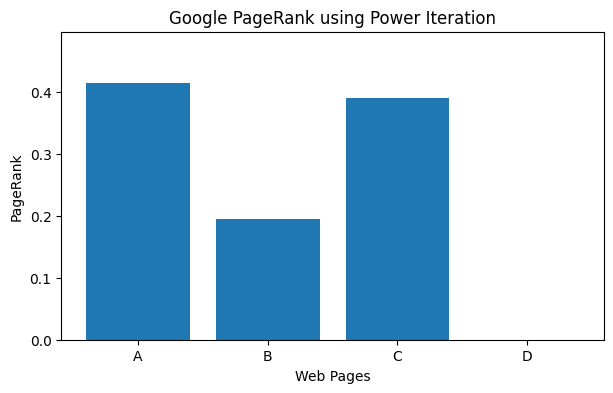

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(pages, rank)

plt.xlabel("Web Pages")
plt.ylabel("PageRank")
plt.title("Google PageRank using Power Iteration")

plt.ylim(0, max(rank) * 1.2)
plt.show()